Importing Libraries

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


Loading Datasets

In [3]:
customers = pd.read_csv("Customers.csv")
products = pd.read_csv("Products.csv")
transactions = pd.read_csv("Transactions - Transactions.csv")

In [4]:
print("Customers Data:")
print(customers.head())
print("\nProducts Data:")
print(products.head())
print("\nTransactions Data:")
print(transactions.head())

Customers Data:
  CustomerID        CustomerName         Region  SignupDate
0      C0001    Lawrence Carroll  South America  2022-07-10
1      C0002      Elizabeth Lutz           Asia  2022-02-13
2      C0003      Michael Rivera  South America  2024-03-07
3      C0004  Kathleen Rodriguez  South America  2022-10-09
4      C0005         Laura Weber           Asia  2022-08-15

Products Data:
  ProductID              ProductName     Category   Price
0      P001     ActiveWear Biography        Books  169.30
1      P002    ActiveWear Smartwatch  Electronics  346.30
2      P003  ComfortLiving Biography        Books   44.12
3      P004            BookWorld Rug   Home Decor   95.69
4      P005          TechPro T-Shirt     Clothing  429.31

Transactions Data:
  TransactionID CustomerID ProductID      TransactionDate  Quantity  \
0        T00001      C0199      P067  2024-08-25 12:38:23         1   
1        T00112      C0146      P067  2024-05-27 22:23:54         1   
2        T00166      C0127 

Checking Null values in Dataset

In [5]:
print("\nMissing Values:")
print(pd.concat([customers.isnull().sum(), products.isnull().sum(), transactions.isnull().sum()], axis=1))


Missing Values:
                   0    1    2
CustomerID       0.0  NaN  0.0
CustomerName     0.0  NaN  NaN
Region           0.0  NaN  NaN
SignupDate       0.0  NaN  NaN
ProductID        NaN  0.0  0.0
ProductName      NaN  0.0  NaN
Category         NaN  0.0  NaN
Price            NaN  0.0  0.0
TransactionID    NaN  NaN  0.0
TransactionDate  NaN  NaN  0.0
Quantity         NaN  NaN  0.0
TotalValue       NaN  NaN  0.0


In [6]:
print("\nTransactions Summary:")
print(transactions.describe())


Transactions Summary:
          Quantity   TotalValue       Price
count  1000.000000  1000.000000  1000.00000
mean      2.537000   689.995560   272.55407
std       1.117981   493.144478   140.73639
min       1.000000    16.080000    16.08000
25%       2.000000   295.295000   147.95000
50%       3.000000   588.880000   299.93000
75%       4.000000  1011.660000   404.40000
max       4.000000  1991.040000   497.76000


In [7]:
merged_df = transactions.merge(customers, on='CustomerID').merge(products, on='ProductID')

Transactions Summary Statistics

In [10]:
print("\nTransactions Summary:")
print(transactions.describe())


Transactions Summary:
          Quantity   TotalValue       Price
count  1000.000000  1000.000000  1000.00000
mean      2.537000   689.995560   272.55407
std       1.117981   493.144478   140.73639
min       1.000000    16.080000    16.08000
25%       2.000000   295.295000   147.95000
50%       3.000000   588.880000   299.93000
75%       4.000000  1011.660000   404.40000
max       4.000000  1991.040000   497.76000


 Business Insights

In [19]:
print("\nTop Selling Products:")
top_products = merged_df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False)
print(top_products.head(10))


Top Selling Products:
ProductName
ActiveWear Smartwatch    100
SoundWave Headphones      97
HomeSense Desk Lamp       81
ActiveWear Rug            79
SoundWave Cookbook        78
ActiveWear Jacket         76
BookWorld Biography       71
TechPro T-Shirt           66
SoundWave Desk Lamp       64
TechPro Textbook          62
Name: Quantity, dtype: int64


Graph Representation of Business Insights

C:\Users\mayur\AppData\Local\Temp\ipykernel_2960\599660485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.head(10).index, y=top_products.head(10).values, palette="Blues")


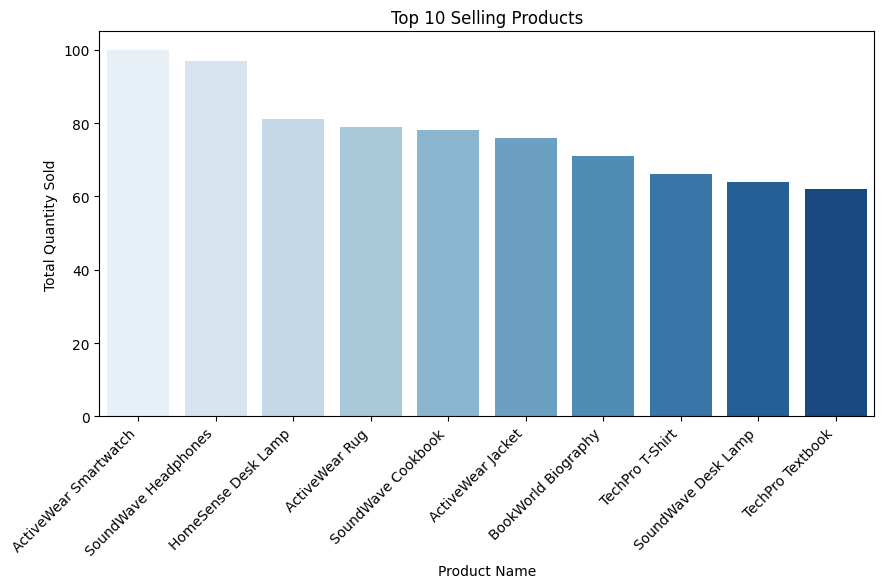

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.head(10).index, y=top_products.head(10).values, palette="Blues")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Product Name")
plt.ylabel("Total Quantity Sold")
plt.title("Top 10 Selling Products")
plt.show()

Sales by region


C:\Users\mayur\AppData\Local\Temp\ipykernel_2960\269851960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=merged_df["Region"], y=merged_df["TotalValue"], palette="coolwarm")


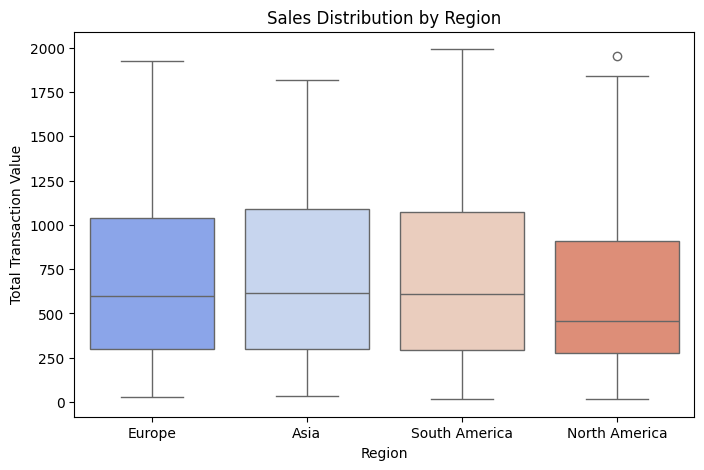

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=merged_df["Region"], y=merged_df["TotalValue"], palette="coolwarm")
plt.xlabel("Region")
plt.ylabel("Total Transaction Value")
plt.title("Sales Distribution by Region")
plt.show()